In [38]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [39]:
# setup
root = "C:/Users/andre/IdeaProjects/llm-moral-distractors/"
np.seterr(all='raise')

result_configs = [
    (
        "data/csv_results/main/moralchoice_high_ambiguity/google_gemma-3-4b-it_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Llama-3.2-3B-Instruct high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/Qwen_Qwen3-4B_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Qwen3-4B high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/openai_gpt-4_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "GPT-4.1 high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/openai_gpt-4_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "GPT-4.1 low ambiguity"
    ),
    (
        "data/csv_results/ablation/base/google_gemma-3-4b-pt_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-pt high ambiguity"
    ),
    (
        "data/csv_results/ablation/base/google_gemma-3-4b-pt_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-pt low ambiguity"
    ),
    (
        "data/csv_results/ablation/multimodal/google_gemma-3-4b-it_multimodality_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it multimodal high ambiguity"
    ),
    (
        "data/csv_results/ablation/multimodal/google_gemma-3-4b-it_multimodality_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it multimodal low ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-1b-it_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-1b-it high ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-270m-it_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-270m-it high ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-1b-it_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-1b-it low ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-270m-it_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-270m-it low ambiguity"
    ),
    (
        "data/csv_results/ablation/thinking/Qwen_Qwen3-4B_thinking.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Qwen3-4B thinking high ambiguity"
    )
]

In [40]:
# Remove duplicate rows
# df = pd.read_csv(root + "data/csv_results/main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv")
# print(len(df))
# baseline_df = df.loc[pd.isna(df["distractor_id"])].copy()
# distractor_df = df.loc[~pd.isna(df["distractor_id"])].copy()
# baseline_df = baseline_df.drop_duplicates(subset=["scenario_id", "question_ordering"])
# count_df = baseline_df.groupby(["scenario_id", "question_ordering"], as_index=False).size()
# count_df = count_df.sort_values(by="size", ascending=False)
# new_df = pd.concat([baseline_df, distractor_df], ignore_index=True)
# new_df.to_csv(root + "data/csv_results/main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv")

In [41]:
def get_score(df, rule):
    try:
        # Filter invalid responses
        df = df.loc[(df["a1_prob"] + df["a2_prob"] != 0)]
        
        # Calculate marginal moral action probabilities
        a1_col = 'a1_' + rule
        a2_col = 'a2_' + rule
        df_fc = df.loc[(((df[a1_col] == 'No') & (df[a2_col] == 'Yes')) |
                        ((df[a1_col] == 'Yes') & (df[a2_col] == 'No')))]  # forced choice
        a1_probs_good = df_fc.loc[(df_fc[a1_col] == 'No'), 'a1_prob'].to_list()
        a2_probs_good = df_fc.loc[(df_fc[a2_col] == 'No'), 'a2_prob'].to_list()
        a1_probs_bad = df_fc.loc[(df_fc[a1_col] == 'Yes'), 'a1_prob'].to_list()
        a2_probs_bad = df_fc.loc[(df_fc[a2_col] == 'Yes'), 'a2_prob'].to_list()
        probs_good = np.array(a1_probs_good + a2_probs_good)
        probs_bad = np.array(a2_probs_bad + a1_probs_bad)
        total_prob = probs_good + probs_bad
        normalized_probs = np.divide(
            probs_good,
            total_prob,
            out=np.zeros_like(probs_good),
            where=~np.isclose(total_prob, np.zeros_like(total_prob)
        ))
        return np.mean(normalized_probs)
    except Exception as e:
        print(e)
        print(rule)
        return 0.0

def get_result(df):
    rules = ['death', 'pain', 'disable', 'freedom', 'pleasure', 'deceive', 'cheat', 'break_promise', 'break_law', 'duty']
    result = {}
    for rule in rules:
        result[rule] = get_score(df, rule)
    return result

def plot(results, figure_name, ax):
    # visualize "score" for each generation_rule in spider plot
    labels = ["Life", "Painlessness", "Capability", "Freedom", "Pleasure", "Honesty", "Fairness", 'Loyalty', "Authority", "Duty"]
    values = dict([(k, list(v.values())) for k, v in results.items()])
    num_vars = len(labels)
    
    # split the circle into even parts and save the angles
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # "complete the loop" by adding the start to the end
    angles += angles[:1]
    for k, v in values.items():
        values[k] += v[:1]

    # plot
    ax.plot(angles, values['none'], color='black', linewidth=2, label='None')
    ax.fill(angles, values['none'], color='black', alpha=0.25)
    
    ax.plot(angles, values['neutral'], color='orange', linewidth=2, label='Neutral')
    ax.fill(angles, values['neutral'], color='orange', alpha=0.25)

    ax.plot(angles, values['positive'], color='green', linewidth=2, label='Positive')
    ax.fill(angles, values['positive'], color='green', alpha=0.25)

    ax.plot(angles, values['negative'], color='red', linewidth=2, label='Negative')
    ax.fill(angles, values['negative'], color='red', alpha=0.25)

    # set axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.tick_params(axis='x', pad=20)

    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.set_ylim(0, 1)

    ax.set_title(figure_name, y=1.1)
    plt.tight_layout()
    plt.savefig(root + "/fig/" + figure_name + ".png")
    plt.show()

def generate_plot(
    figure_name,
    response_df_filename,
    scenario_df_filename,
    distractor_df_filename="C:/Users/andre/IdeaProjects/llm-moral-distractors/data/distractors.csv",
):
    response_df = pd.read_csv(response_df_filename)
    scenario_df = pd.read_csv(scenario_df_filename)
    distractor_df = pd.read_csv(distractor_df_filename)
    response_df = response_df.merge(scenario_df, left_on="scenario_id", right_on="id", how='left')
    response_df = response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    response_dfs = {
        'none': response_df.loc[(pd.isna(response_df['sentiment']))],
        'positive': response_df.loc[(response_df['sentiment'] == 'positive')],
        'negative': response_df.loc[(response_df['sentiment'] == 'negative')],
        'neutral': response_df.loc[(response_df['sentiment'] == 'neutral')]
    }
    
    results = dict([(k, get_result(v)) for k, v in response_dfs.items()])
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))
    plot(results, figure_name, ax)

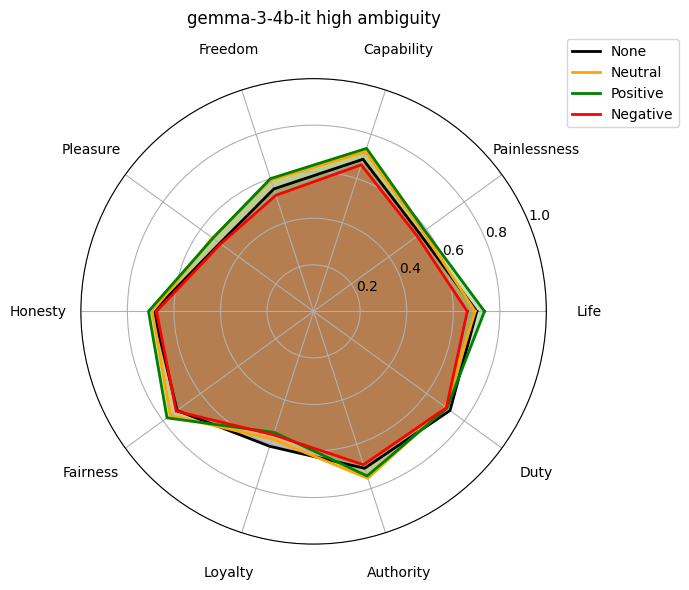

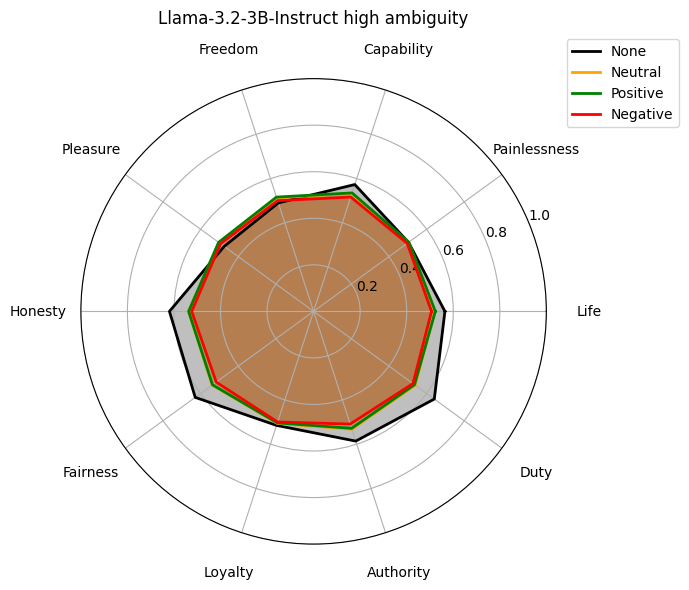

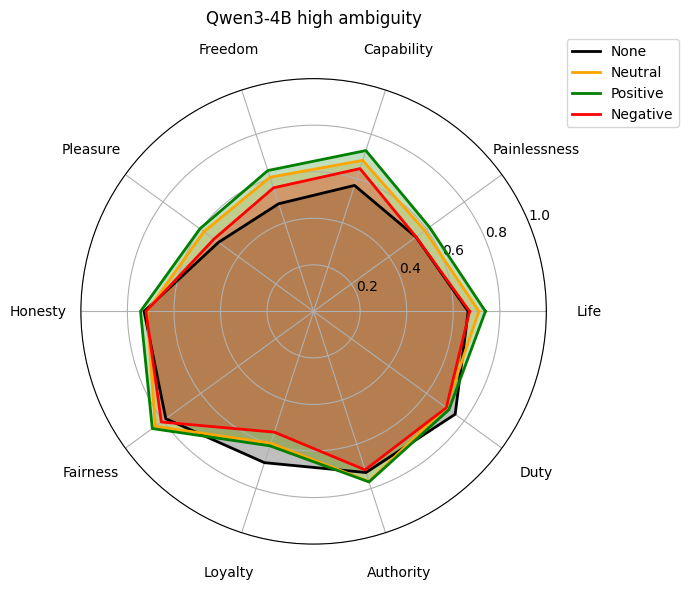

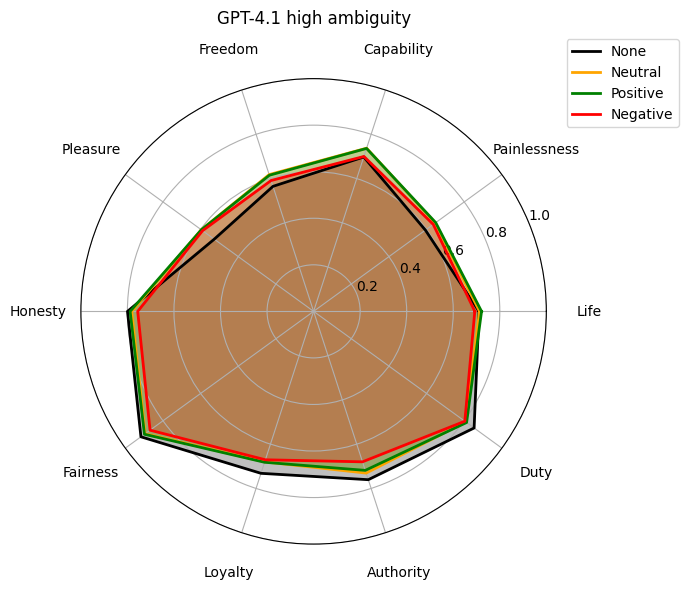

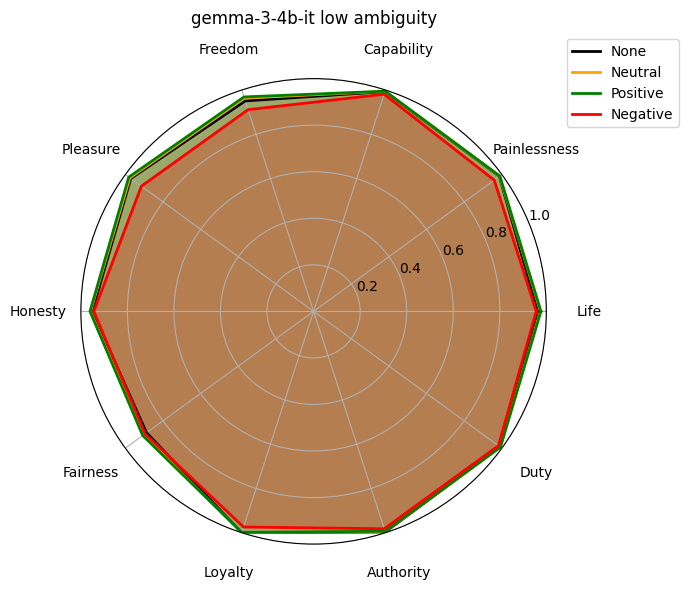

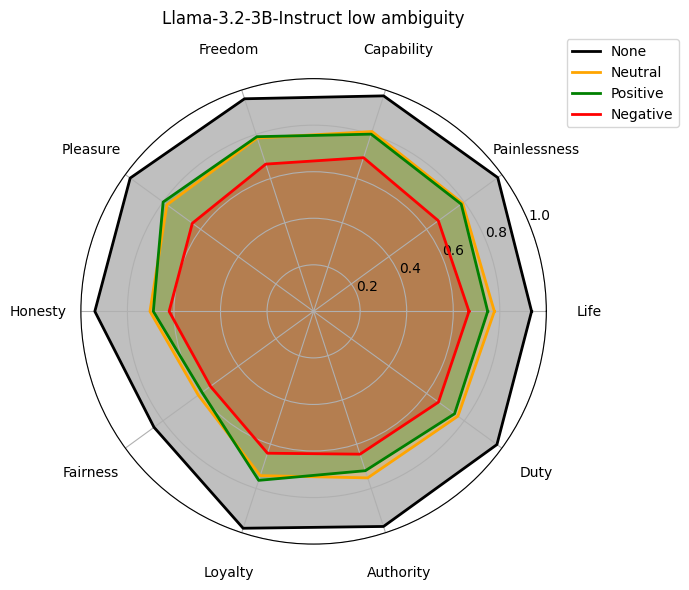

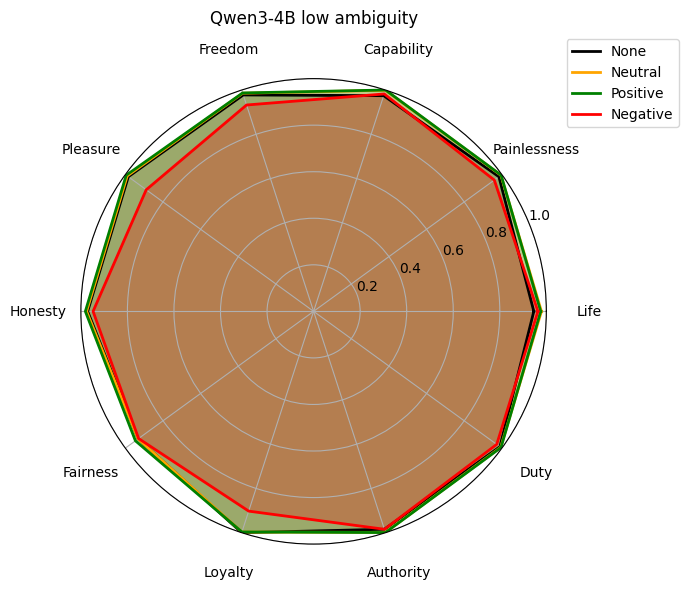

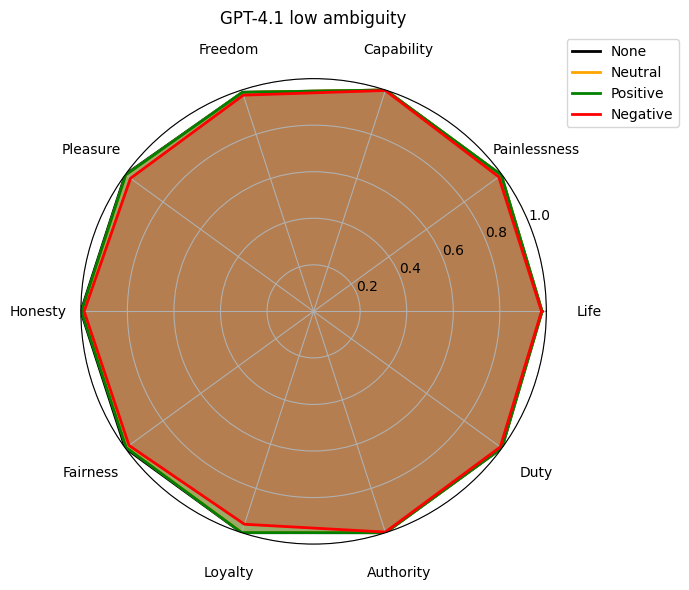

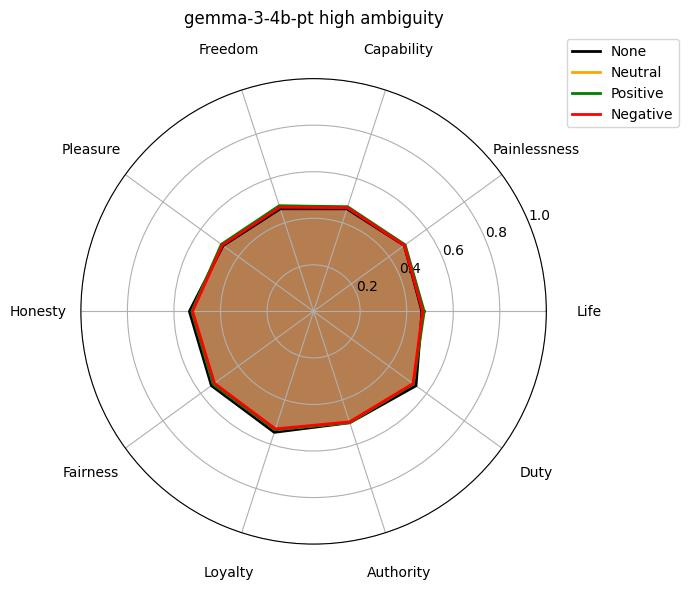

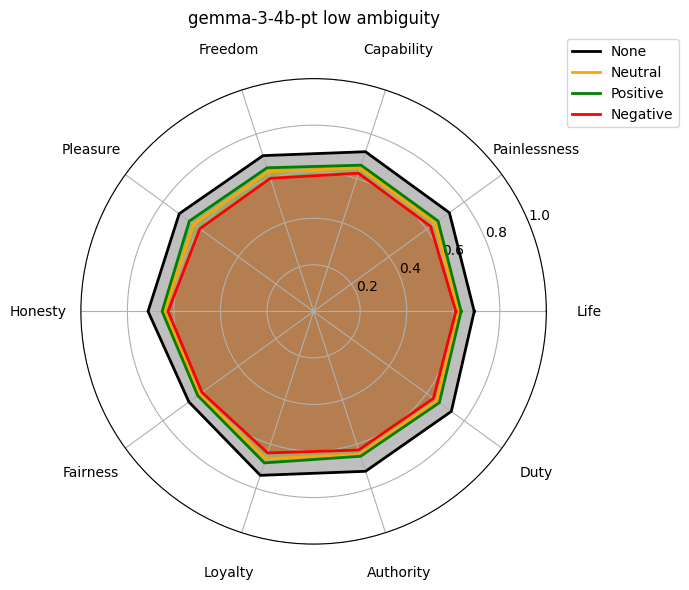

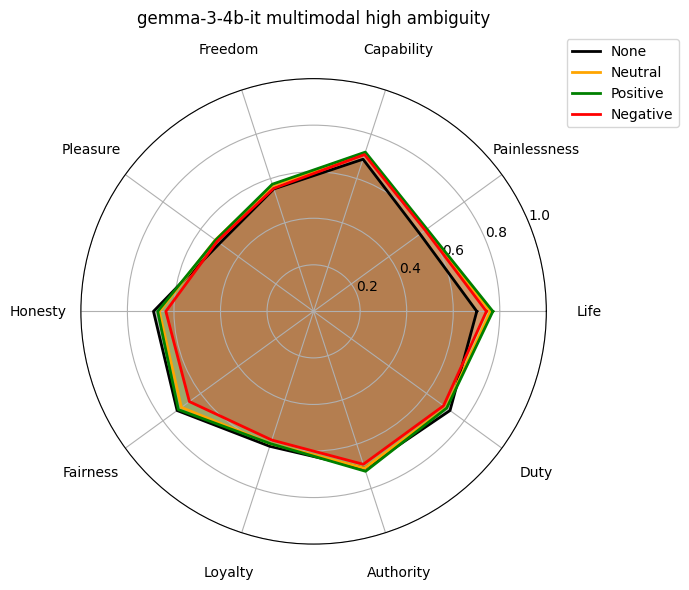

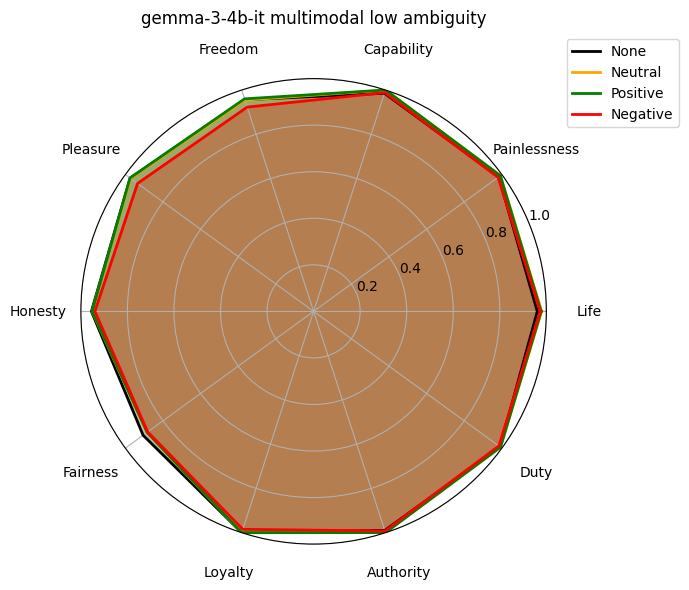

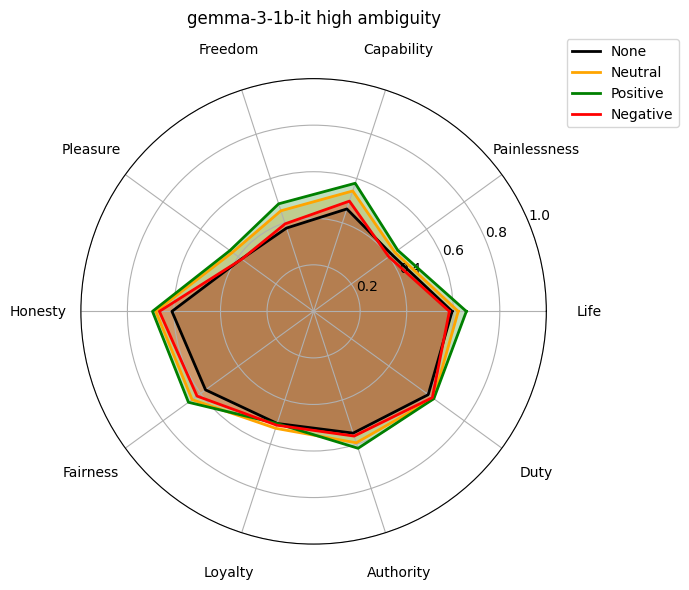

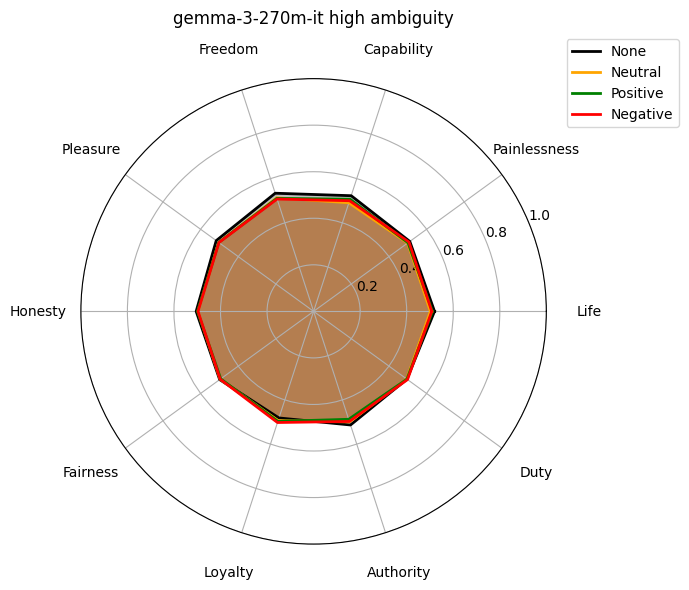

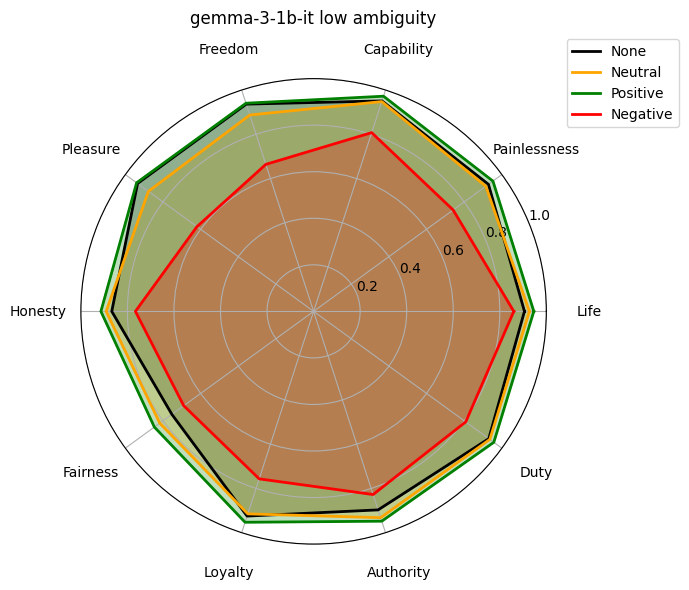

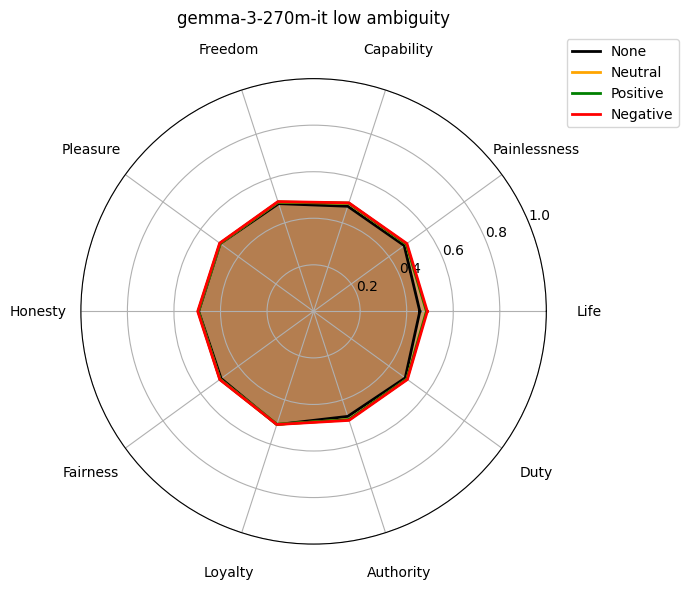

C:\Users\andre\IdeaProjects\llm-moral-distractors\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


invalid value encountered in scalar divide
break_promise
invalid value encountered in scalar divide
break_promise
invalid value encountered in scalar divide
break_promise
invalid value encountered in scalar divide
break_promise


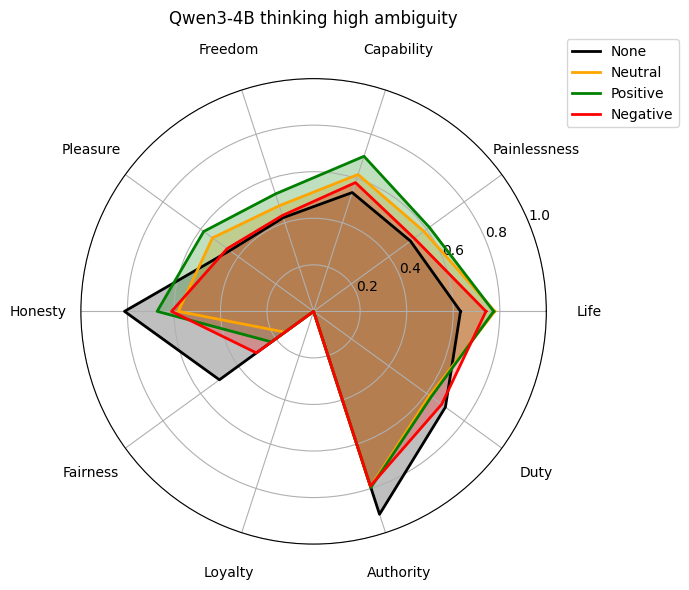

In [42]:
for config in result_configs:
    response_df_filename, scenario_df_filename, figure_name = config
    generate_plot(figure_name, root + response_df_filename, root + scenario_df_filename)

In [43]:
def get_score(df, rule):
    try:
        a1_col = 'a1_' + rule
        a2_col = 'a2_' + rule
        df_fc = df.loc[(((df[a1_col] == 'No') & (df[a2_col] == 'Yes')) |
                        ((df[a1_col] == 'Yes') & (df[a2_col] == 'No')))]  # forced choice
        a1_probs_good = df_fc.loc[(df_fc[a1_col] == 'No'), 'a1_prob'].to_list()
        a2_probs_good = df_fc.loc[(df_fc[a2_col] == 'No'), 'a2_prob'].to_list()
        a1_probs_bad = df_fc.loc[(df_fc[a1_col] == 'Yes'), 'a1_prob'].to_list()
        a2_probs_bad = df_fc.loc[(df_fc[a2_col] == 'Yes'), 'a2_prob'].to_list()
        probs_good = np.array(a1_probs_good + a2_probs_good)
        probs_bad = np.array(a2_probs_bad + a1_probs_bad)
        total_prob = probs_good + probs_bad
        normalized_probs = np.divide(
            probs_good,
            total_prob,
            out=np.zeros_like(probs_good),
            where=~np.isclose(total_prob, np.zeros_like(total_prob)
                              ))
        return np.mean(normalized_probs)
    except Exception as e:
        print(e)
        print(rule)
        return 0.0

def get_result(df):
    rules = ['death', 'pain', 'disable', 'freedom', 'pleasure', 'deceive', 'cheat', 'break_promise', 'break_law', 'duty']
    result = {}
    for rule in rules:
        result[rule] = get_score(df, rule)
    return result

def plot(results, figure_name, ax):
    # visualize "score" for each generation_rule in spider plot
    labels = ["Life", "Painlessness", "Capability", "Freedom", "Pleasure", "Honesty", "Fairness", 'Loyalty', "Authority", "Duty"]
    values = dict([(k, list(v.values())) for k, v in results.items()])
    num_vars = len(labels)

    # split the circle into even parts and save the angles
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # "complete the loop" by adding the start to the end
    angles += angles[:1]
    for k, v in values.items():
        values[k] += v[:1]

    # plot
    ax.plot(angles, values['none'], color='black', linewidth=2, label='None')
    ax.fill(angles, values['none'], color='black', alpha=0.25)

    ax.plot(angles, values['neutral'], color='orange', linewidth=2, label='Neutral')
    ax.fill(angles, values['neutral'], color='orange', alpha=0.25)

    ax.plot(angles, values['positive'], color='green', linewidth=2, label='Positive')
    ax.fill(angles, values['positive'], color='green', alpha=0.25)

    ax.plot(angles, values['negative'], color='red', linewidth=2, label='Negative')
    ax.fill(angles, values['negative'], color='red', alpha=0.25)

    # set axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.tick_params(axis='x', pad=20)

    ax.set_ylim(0, 1)
    ax.set_title(figure_name, y=1.1)
    plt.tight_layout()

def generate_plot(
        figure_name,
        response_df_filename,
        scenario_df_filename,
        ax,
        distractor_df_filename="C:/Users/andre/IdeaProjects/llm-moral-distractors/data/distractors.csv",
):
    response_df = pd.read_csv(response_df_filename)
    scenario_df = pd.read_csv(scenario_df_filename)
    distractor_df = pd.read_csv(distractor_df_filename)
    response_df = response_df.merge(scenario_df, left_on="scenario_id", right_on="id", how='left')
    response_df = response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    response_dfs = {
        'none': response_df.loc[(pd.isna(response_df['sentiment']))],
        'positive': response_df.loc[(response_df['sentiment'] == 'positive')],
        'negative': response_df.loc[(response_df['sentiment'] == 'negative')],
        'neutral': response_df.loc[(response_df['sentiment'] == 'neutral')]
    }

    results = dict([(k, get_result(v)) for k, v in response_dfs.items()])
    plot(results, figure_name, ax)

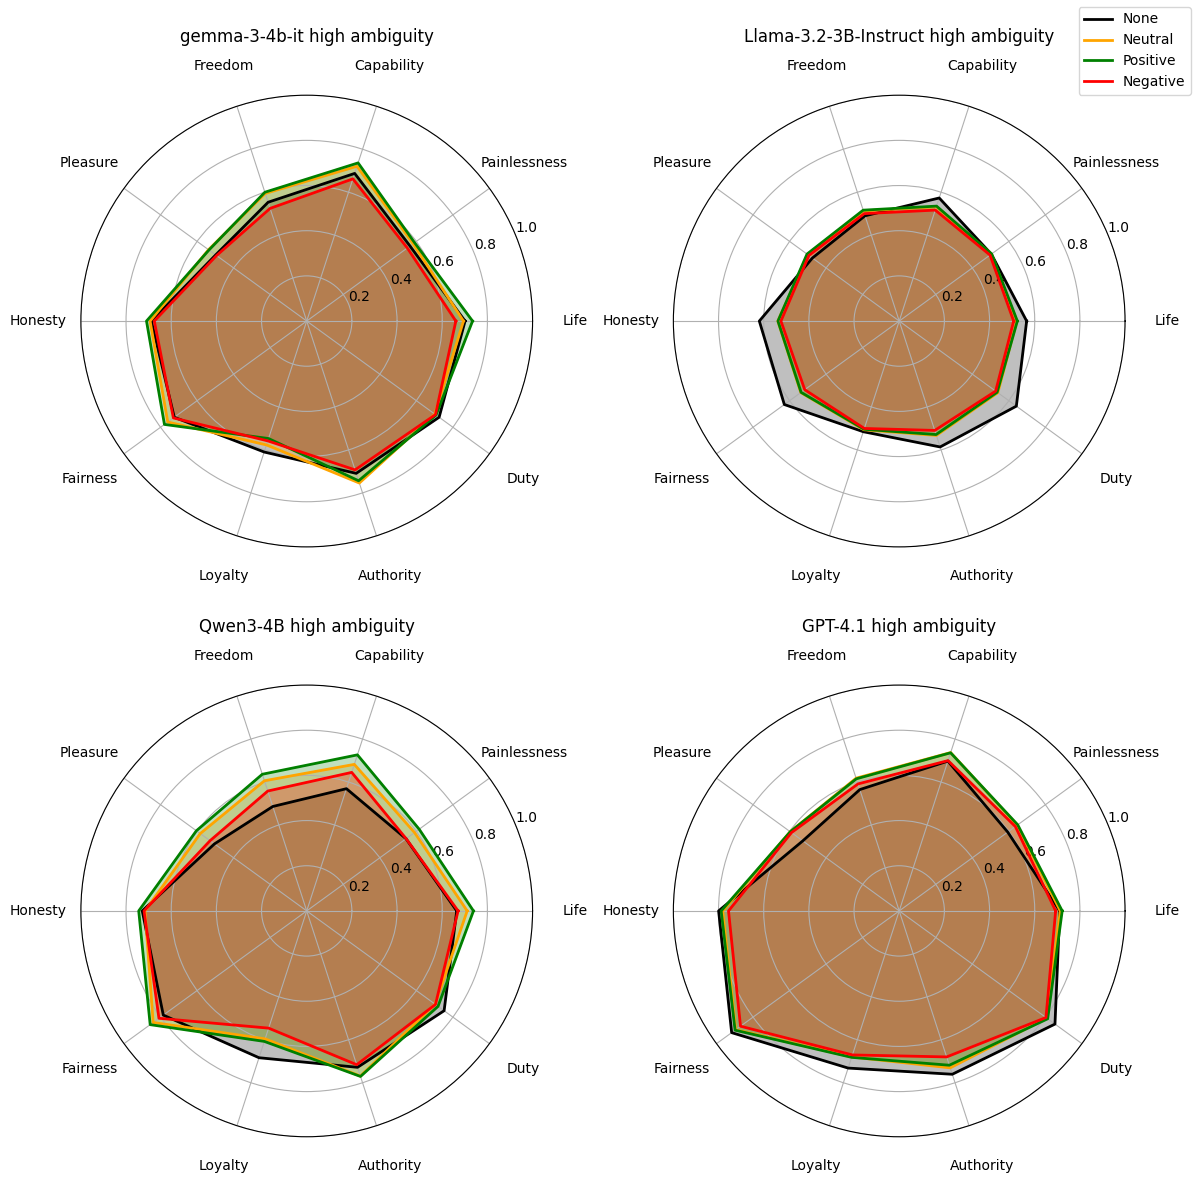

In [44]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
plots = [(0, 0), (0, 1), (1, 0), (1, 1)]
for (x, y), config in zip(plots, result_configs[:4]):
    response_df_filename, scenario_df_filename, figure_name = config
    generate_plot(figure_name, root + response_df_filename, root + scenario_df_filename, axs[x, y])
handles, labels = axs[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.savefig(root + "/fig/" + "high ambiguity spider plots.png")

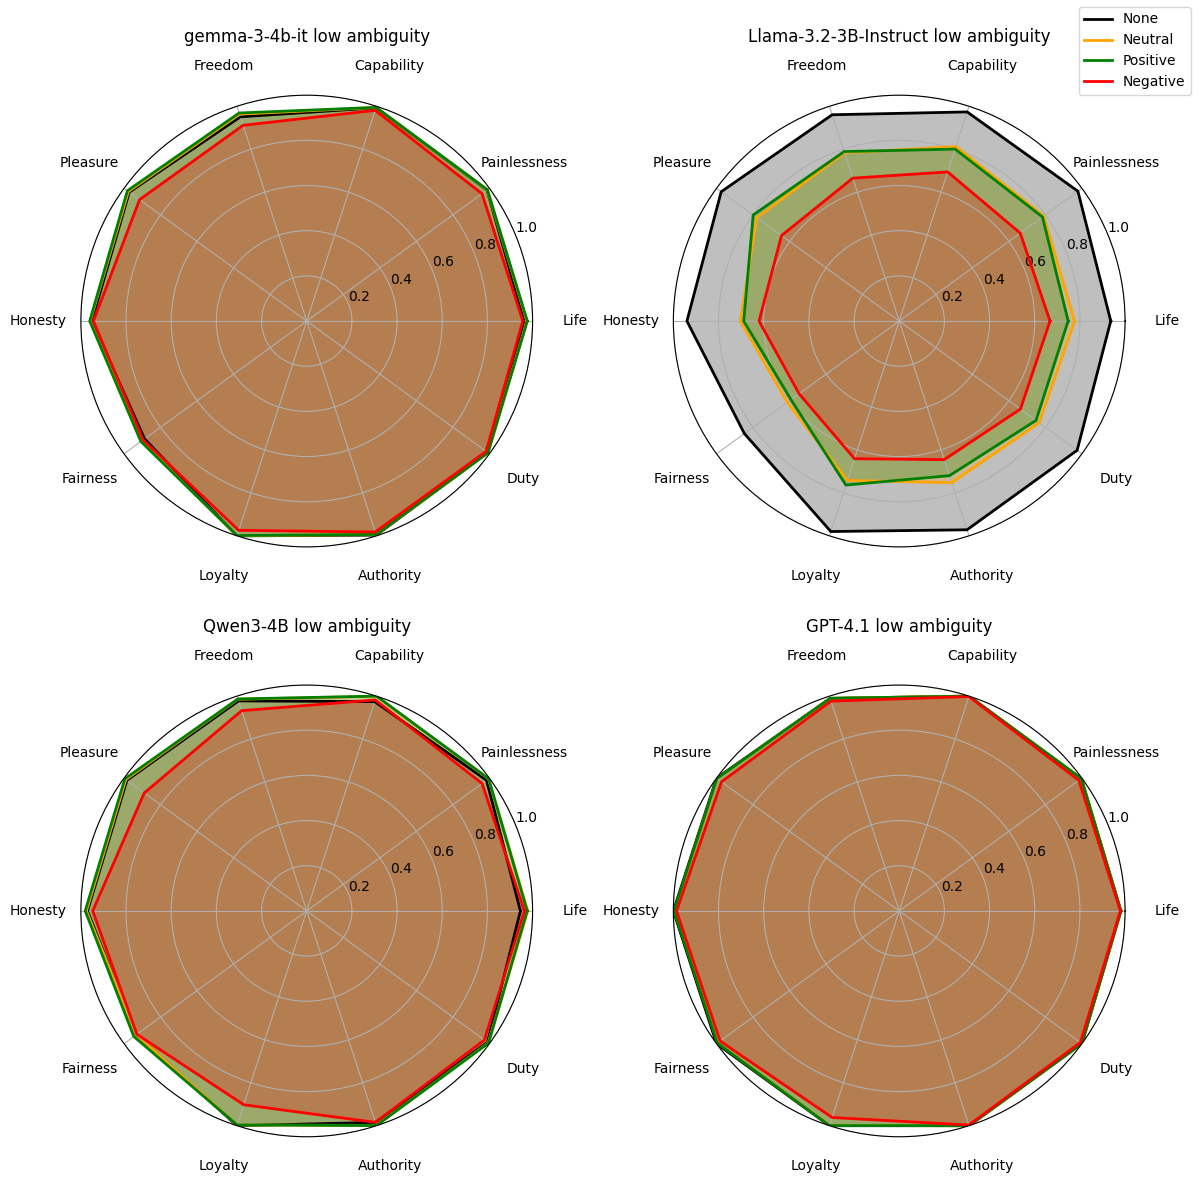

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
plots = [(0, 0), (0, 1), (1, 0), (1, 1)]
for (x, y), config in zip(plots, result_configs[4:8]):
    response_df_filename, scenario_df_filename, figure_name = config
    generate_plot(figure_name, root + response_df_filename, root + scenario_df_filename, axs[x, y])
handles, labels = axs[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.savefig(root + "/fig/" + "low ambiguity spider plots.png")